<a href="https://qworld.net" target="_blank" align="left"><img src="../../qworld/images/header.jpg"  align="left"></a>
$ \newcommand{\bra}[1]{\langle #1|} $
$ \newcommand{\ket}[1]{|#1\rangle} $
$ \newcommand{\braket}[2]{\langle #1|#2\rangle} $
$ \newcommand{\dot}[2]{ #1 \cdot #2} $
$ \newcommand{\biginner}[2]{\left\langle #1,#2\right\rangle} $
$ \newcommand{\mymatrix}[2]{\left( \begin{array}{#1} #2\end{array} \right)} $
$ \newcommand{\myvector}[1]{\mymatrix{c}{#1}} $
$ \newcommand{\myrvector}[1]{\mymatrix{r}{#1}} $
$ \newcommand{\mypar}[1]{\left( #1 \right)} $
$ \newcommand{\mybigpar}[1]{ \Big( #1 \Big)} $
$ \newcommand{\sqrttwo}{\frac{1}{\sqrt{2}}} $
$ \newcommand{\dsqrttwo}{\dfrac{1}{\sqrt{2}}} $
$ \newcommand{\onehalf}{\frac{1}{2}} $
$ \newcommand{\donehalf}{\dfrac{1}{2}} $
$ \newcommand{\hadamard}{ \mymatrix{rr}{ \sqrttwo & \sqrttwo \\ \sqrttwo & -\sqrttwo }} $
$ \newcommand{\vzero}{\myvector{1\\0}} $
$ \newcommand{\vone}{\myvector{0\\1}} $
$ \newcommand{\stateplus}{\myvector{ \sqrttwo \\  \sqrttwo } } $
$ \newcommand{\stateminus}{ \myrvector{ \sqrttwo \\ -\sqrttwo } } $
$ \newcommand{\myarray}[2]{ \begin{array}{#1}#2\end{array}} $
$ \newcommand{\X}{ \mymatrix{cc}{0 & 1 \\ 1 & 0}  } $
$ \newcommand{\I}{ \mymatrix{rr}{1 & 0 \\ 0 & 1}  } $
$ \newcommand{\Z}{ \mymatrix{rr}{1 & 0 \\ 0 & -1}  } $
$ \newcommand{\Htwo}{ \mymatrix{rrrr}{ \frac{1}{2} & \frac{1}{2} & \frac{1}{2} & \frac{1}{2} \\ \frac{1}{2} & -\frac{1}{2} & \frac{1}{2} & -\frac{1}{2} \\ \frac{1}{2} & \frac{1}{2} & -\frac{1}{2} & -\frac{1}{2} \\ \frac{1}{2} & -\frac{1}{2} & -\frac{1}{2} & \frac{1}{2} } } $
$ \newcommand{\CNOT}{ \mymatrix{cccc}{1 & 0 & 0 & 0 \\ 0 & 1 & 0 & 0 \\ 0 & 0 & 0 & 1 \\ 0 & 0 & 1 & 0} } $
$ \newcommand{\norm}[1]{ \left\lVert #1 \right\rVert } $
$ \newcommand{\pstate}[1]{ \lceil \mspace{-1mu} #1 \mspace{-1.5mu} \rfloor } $
$ \newcommand{\greenbit}[1] {\mathbf{{\color{green}#1}}} $
$ \newcommand{\bluebit}[1] {\mathbf{{\color{blue}#1}}} $
$ \newcommand{\redbit}[1] {\mathbf{{\color{red}#1}}} $
$ \newcommand{\brownbit}[1] {\mathbf{{\color{brown}#1}}} $
$ \newcommand{\blackbit}[1] {\mathbf{{\color{black}#1}}} $

# Solutions - Observables, Measurement, and Readout

_Prepared by Claudia Zendejas-Morales_

This notebook contains complete solutions for the embedded tasks in notebook `2.4`.


In [6]:
import numpy as np
import matplotlib.pyplot as plt

from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector, SparsePauliOp

import pennylane as qml


<a id="task1-solution"></a>

## Task 1 (coding): One complete solution

We reproduce the exact observable readout in Qiskit and add the additional observable $X_0 X_1$.


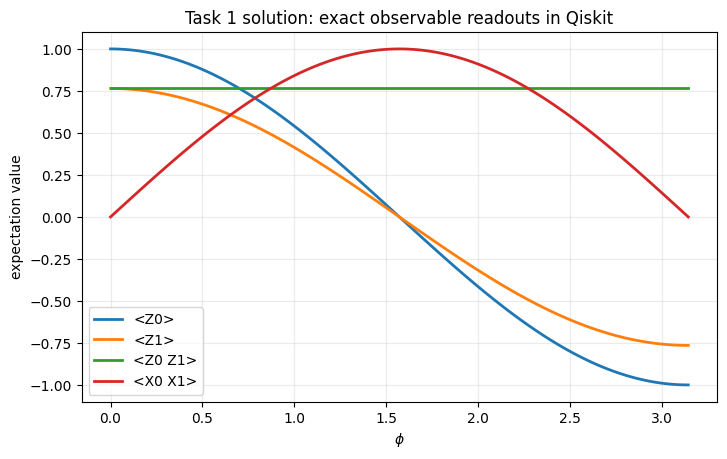

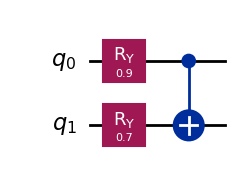

Largest |<XX>-<ZZ>| on the sampled grid occurs near phi=0.000
At that point: <XX>=0.000, <ZZ>=0.765


In [7]:
def qiskit_correlated_circuit(phi):
    qc = QuantumCircuit(2)
    qc.ry(phi, 0)
    qc.ry(0.70, 1)
    qc.cx(0, 1)
    return qc

ops = {
    "<Z0>": SparsePauliOp.from_list([("IZ", 1.0)]),
    "<Z1>": SparsePauliOp.from_list([("ZI", 1.0)]),
    "<Z0 Z1>": SparsePauliOp.from_list([("ZZ", 1.0)]),
    "<X0 X1>": SparsePauliOp.from_list([("XX", 1.0)]),
}

def observable_curves_qiskit(phis):
    curves = {label: [] for label in ops}
    for phi in phis:
        sv = Statevector.from_instruction(qiskit_correlated_circuit(phi))
        for label, op in ops.items():
            curves[label].append(float(np.real(sv.expectation_value(op))))
    return curves

phis = np.linspace(0.0, np.pi, 121)
curves = observable_curves_qiskit(phis)

plt.figure(figsize=(8.2, 4.8))
for label, values in curves.items():
    plt.plot(phis, values, linewidth=2, label=label)
plt.xlabel(r"$\phi$")
plt.ylabel("expectation value")
plt.title("Task 1 solution: exact observable readouts in Qiskit")
plt.grid(alpha=0.25)
plt.legend()
plt.show()

display(qiskit_correlated_circuit(0.90).draw("mpl"))

diff = np.abs(np.array(curves["<X0 X1>"]) - np.array(curves["<Z0 Z1>"]))
idx_max = int(np.argmax(diff))
print(f"Largest |<XX>-<ZZ>| on the sampled grid occurs near phi={phis[idx_max]:.3f}")
print(f"At that point: <XX>={curves['<X0 X1>'][idx_max]:.3f}, <ZZ>={curves['<Z0 Z1>'][idx_max]:.3f}")


The observable choice changes which feature of the state is being compressed into a scalar. Here $\langle Z_0 Z_1 \rangle$ and $\langle X_0 X_1 \rangle$ respond differently to the same family of states, so the readout is genuinely part of the model design.


<a id="task2-solution"></a>

## Task 2 (coding): One complete solution

We repeat the shot-noise experiment in PennyLane by comparing repeated estimates of $\langle Z \rangle$ for different shot budgets.


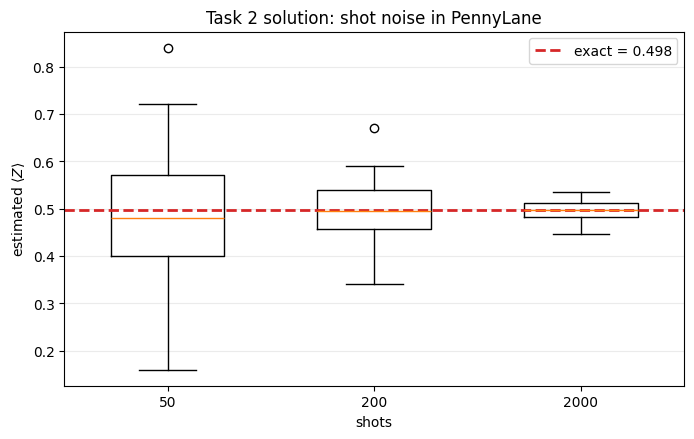

shots=  50 -> mean=0.4860, std=0.1276
shots= 200 -> mean=0.4959, std=0.0618
shots=2000 -> mean=0.4959, std=0.0195


In [8]:
phi = 1.05
shots_list = [50, 200, 2000]
repeats = 80

dev_exact = qml.device("default.qubit", wires=1)

@qml.qnode(dev_exact)
def exact_z_pennylane(phi):
    qml.RY(phi, wires=0)
    return qml.expval(qml.PauliZ(0))

def make_sampled_qnode(seed):
    dev = qml.device("default.qubit", wires=1, seed=seed)

    @qml.qnode(dev)
    def sampled_circuit(phi):
        qml.RY(phi, wires=0)
        return qml.sample(qml.PauliZ(0))

    return sampled_circuit

def sampled_z_estimates_pennylane(phi, shots, repeats=80, base_seed=0):
    estimates = []
    for k in range(repeats):
        sampled_circuit = make_sampled_qnode(base_seed + k)
        sampled_with_shots = qml.set_shots(sampled_circuit, shots=shots)
        outcomes = sampled_with_shots(phi)
        estimates.append(float(np.mean(outcomes)))
    return np.array(estimates)

exact_value = float(exact_z_pennylane(phi))
estimates = {shots: sampled_z_estimates_pennylane(phi, shots, repeats=repeats) for shots in shots_list}

plt.figure(figsize=(8, 4.6))
data = [estimates[shots] for shots in shots_list]
plt.boxplot(data, tick_labels=[str(shots) for shots in shots_list], widths=0.55)
plt.axhline(exact_value, color="#d62728", linestyle="--", linewidth=2, label=f"exact = {exact_value:.3f}")
plt.xlabel("shots")
plt.ylabel(r"estimated $\langle Z \rangle$")
plt.title("Task 2 solution: shot noise in PennyLane")
plt.grid(axis="y", alpha=0.25)
plt.legend()
plt.show()

for shots in shots_list:
    values = estimates[shots]
    print(f"shots={shots:4d} -> mean={values.mean():.4f}, std={values.std(ddof=1):.4f}")

The empirical means stay close to the exact value, while the empirical standard deviation shrinks as the shot budget grows. This is the usual variance-cost tradeoff of measurement-based estimation.


<a id="task3-solution"></a>

## Task 3 (coding): One complete solution

We compare full-register parity and two-qubit parity on the same three-qubit state family, now using PennyLane to obtain the exact computational-basis probabilities.


phi=0.20 -> full parity=0.496, parity(0,1)=0.506
phi=0.90 -> full parity=0.420, parity(0,1)=0.675
phi=1.60 -> full parity=-0.024, parity(0,1)=0.814
phi=2.30 -> full parity=-0.611, parity(0,1)=0.917

0: ──RY(0.90)─╭●────┤ ╭Probs
1: ──RY(0.85)─╰X─╭●─┤ ├Probs
2: ──RY(0.83)────╰X─┤ ╰Probs


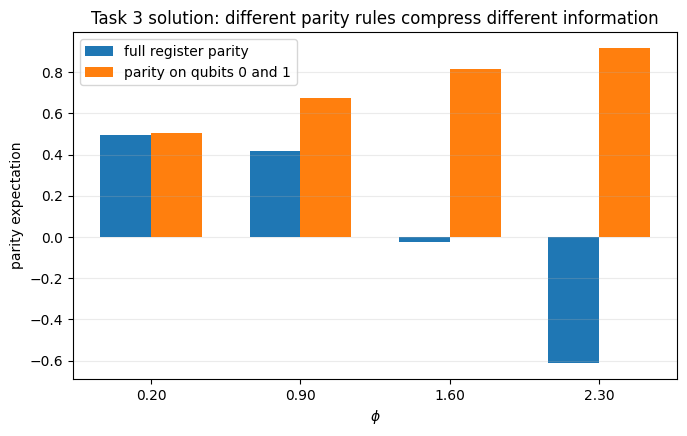

Largest difference occurs at phi=2.30, with absolute gap 1.528


In [9]:
phis = [0.20, 0.90, 1.60, 2.30]

dev_parity = qml.device("default.qubit", wires=3)

@qml.qnode(dev_parity)
def three_qubit_probs(phi):
    qml.RY(phi, wires=0)
    qml.RY(0.85, wires=1)
    qml.RY(1.10 - 0.30 * phi, wires=2)
    qml.CNOT(wires=[0, 1])
    qml.CNOT(wires=[1, 2])
    return qml.probs(wires=[0, 1, 2])

def probs_array_to_dict(probs):
    n_wires = int(np.log2(len(probs)))
    return {
        format(index, f"0{n_wires}b"): float(prob)
        for index, prob in enumerate(probs)
    }

def parity_from_probabilities_dict(probs_dict):
    total = 0.0
    for b_string, prob in probs_dict.items():
        total += ((-1) ** b_string.count("1")) * prob
    return total

def parity_on_subset_from_probabilities_dict(probs_dict, subset):
    total = 0.0
    for b_string, prob in probs_dict.items():
        parity_bits = sum(int(b_string[-1 - q]) for q in subset)
        total += ((-1) ** parity_bits) * prob
    return total

full_values, subset_values = [], []
for phi in phis:
    probs = three_qubit_probs(phi)
    probs_dict = probs_array_to_dict(probs)
    full_parity = parity_from_probabilities_dict(probs_dict)
    subset_parity = parity_on_subset_from_probabilities_dict(probs_dict, subset=[0, 1])
    full_values.append(full_parity)
    subset_values.append(subset_parity)
    print(f"phi={phi:.2f} -> full parity={full_parity:.3f}, parity(0,1)={subset_parity:.3f}")

print()
print(qml.draw(three_qubit_probs)(phis[1]))

plt.figure(figsize=(7.8, 4.5))
x = np.arange(len(phis))
width = 0.34
plt.bar(x - width / 2, full_values, width=width, label="full register parity")
plt.bar(x + width / 2, subset_values, width=width, label="parity on qubits 0 and 1")
plt.xticks(x, [f"{phi:.2f}" for phi in phis])
plt.xlabel(r"$\phi$")
plt.ylabel("parity expectation")
plt.title("Task 3 solution: different parity rules compress different information")
plt.grid(axis="y", alpha=0.25)
plt.legend()
plt.show()

diff = np.abs(np.array(full_values) - np.array(subset_values))
idx = int(np.argmax(diff))
print(f"Largest difference occurs at phi={phis[idx]:.2f}, with absolute gap {diff[idx]:.3f}")


The third qubit matters because full-register parity includes it in the sign pattern, while the restricted parity does not. The two readouts are therefore compressing different aspects of the same probability distribution.


<a id="task4-solution"></a>

## Task 4 (coding): One complete solution

We compare a smaller linear head based on $(\langle Z_0 \rangle, \langle Z_1 \rangle)$ with a richer head that also includes $\langle X_0 \rangle$, now using Qiskit for the exact readout values.


sample                small head        richer head
[0.15 0.35]  ->    0.326 from [0.989 0.929]   |     0.349 from [0.989 0.929 0.051]
[0.65 0.55]  ->    0.287 from [0.796 0.679]   |     0.430 from [0.796 0.679 0.316]
[1.05 0.8 ]  ->    0.200 from [0.498 0.347]   |     0.480 from [0.498 0.347 0.622]
[1.4 0.2]  ->    0.011 from [0.17  0.167]   |     0.099 from [0.17  0.167 0.196]



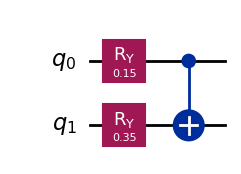

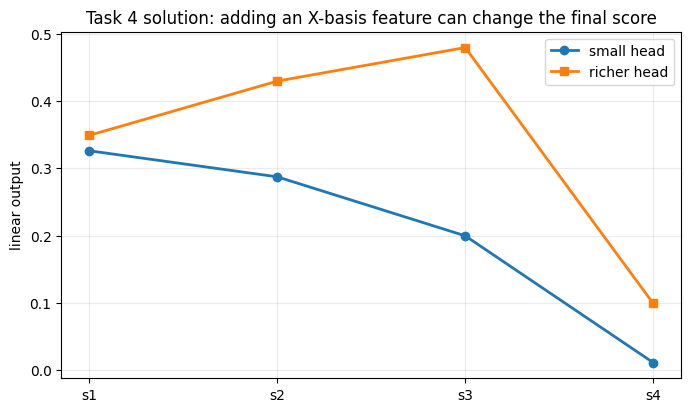

In [10]:
samples_task = [
    np.array([0.15, 0.35]),
    np.array([0.65, 0.55]),
    np.array([1.05, 0.80]),
    np.array([1.40, 0.20]),
]

def qiskit_readout_circuit(sample):
    qc = QuantumCircuit(2)
    qc.ry(sample[0], 0)
    qc.ry(sample[1], 1)
    qc.cx(0, 1)
    return qc

Z0_OP = SparsePauliOp.from_list([("IZ", 1.0)])
Z1_OP = SparsePauliOp.from_list([("ZI", 1.0)])
X0_OP = SparsePauliOp.from_list([("IX", 1.0)])

def z_features(sample):
    sv = Statevector.from_instruction(qiskit_readout_circuit(sample))
    z0 = float(np.real(sv.expectation_value(Z0_OP)))
    z1 = float(np.real(sv.expectation_value(Z1_OP)))
    return np.array([z0, z1], dtype=float)

def x_feature(sample):
    sv = Statevector.from_instruction(qiskit_readout_circuit(sample))
    return float(np.real(sv.expectation_value(X0_OP)))

def linear_head(sample, weights, bias, use_x_term=False):
    base = z_features(sample)
    if use_x_term:
        features = np.concatenate([base, [x_feature(sample)]])
    else:
        features = base
    return features, float(bias + np.dot(weights, features))

small_weights = np.array([0.85, -0.50])
small_bias = -0.05
rich_weights = np.array([0.85, -0.50, 0.45])
rich_bias = -0.05

print('sample                small head        richer head')
small_outputs, rich_outputs = [], []
for sample in samples_task:
    small_features, small_y = linear_head(sample, small_weights, small_bias, use_x_term=False)
    rich_features, rich_y = linear_head(sample, rich_weights, rich_bias, use_x_term=True)
    small_outputs.append(small_y)
    rich_outputs.append(rich_y)
    print(f"{sample}  ->  {small_y:7.3f} from {np.round(small_features, 3)}   |   {rich_y:7.3f} from {np.round(rich_features, 3)}")

print()
display(qiskit_readout_circuit(samples_task[0]).draw('mpl'))

plt.figure(figsize=(8, 4.5))
x = np.arange(len(samples_task))
plt.plot(x, small_outputs, marker='o', linewidth=2, label='small head')
plt.plot(x, rich_outputs, marker='s', linewidth=2, label='richer head')
plt.xticks(x, [f"s{i+1}" for i in range(len(samples_task))])
plt.ylabel('linear output')
plt.title('Task 4 solution: adding an X-basis feature can change the final score')
plt.grid(alpha=0.25)
plt.legend()
plt.show()


A richer head can change the ranking or the sign of outputs because it adds information from a different observable family. Outside a simulator, however, the $X$-basis term would usually require an additional measurement setting, so the richer head also carries additional shot cost.